1. Сделать реализацию выборки объемом N элементов из генеральной совокупности,
распределенной по логнормальному закону распределения с параметрами, указанными в
табл. 1.

In [167]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.optimize import minimize
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [168]:
b = 0.8
a = 2
N = 200

# Генерация выборки
sample = stats.lognorm.rvs(s=b, scale=np.exp(a), size=N)

print(f"Параметры варианта: a={a}, b={b}, N={N}")
print(f"Первые 10 элементов выборки: {sample[:10]}")

Параметры варианта: a=2, b=0.8, N=200
Первые 10 элементов выборки: [ 6.25296668 27.9961136   3.76099824 11.74914646  4.74713877  3.29637592
  2.36347243  7.21512138  6.85788657 11.31504122]


2. На основе полученной выборки построить эмпирическую функцию распределения и
гистограмму эмпирической плотности распределения. На этих же графиках отобразить
теоретические функцию и плотность распределения.

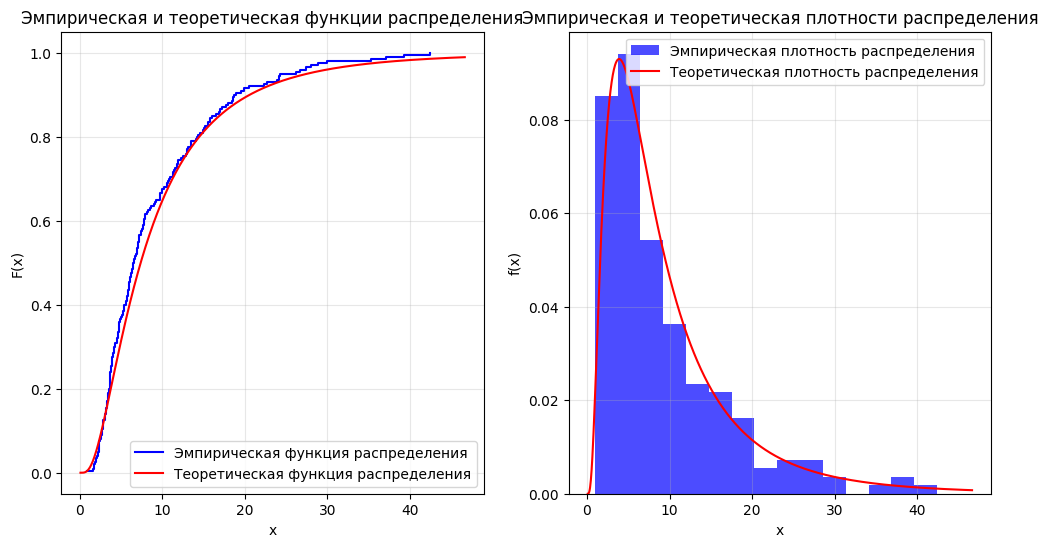

In [169]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
x_sorted = np.sort(sample)
y_esdf = np.arange(1, len(sample) + 1) / len(sample)
plt.step(x_sorted, y_esdf, where='post', label='Эмпирическая функция распределения', color='blue')

#Теоретическая функция распределения
x_theoretical = np.linspace(0.1, max(sample)*1.1, 1000)
y_theoretical = stats.lognorm.cdf(x_theoretical, s=b, scale=np.exp(a))
plt.plot(x_theoretical, y_theoretical, label='Теоретическая функция распределения', color='red')

plt.xlabel('x')
plt.ylabel('F(x)')
plt.title('Эмпирическая и теоретическая функции распределения')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Гистограмма эмпирической плотности распределения
plt.hist(sample, bins=15, density=True, alpha=0.7, label='Эмпирическая плотность распределения', color='blue')

#Теоретическая плотность распределения
x_values = np.linspace(0.1, max(sample)*1.1, 1000)
y_theoretical_p = stats.lognorm.pdf(x_values, s=b, scale=np.exp(a))
plt.plot(x_values, y_theoretical_p, label='Теоретическая плотность распределения', color='red')

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Эмпирическая и теоретическая плотности распределения')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

3.Для полученной выборки построить точечные оценки для математическое ожидание и
дисперсии генеральной совокупности.

In [170]:
mean_sample = np.mean(sample)
var_sample = np.var(sample)
print(f"Оценка математического ожидания: {mean_sample:.4f}")
print(f"Оценка дисперсии: {var_sample:.4f}")

theoretical_mean = np.exp(a + b**2/2)
theoretical_var = np.exp(2*a + b**2)*(np.exp(b**2)-1)
print(f"Теоретическое математическое ожидание: {theoretical_mean:.4f}")
print(f"Теоретическая дисперсия: {theoretical_var:.4f}")

Оценка математического ожидания: 9.2666
Оценка дисперсии: 57.8854
Теоретическое математическое ожидание: 10.1757
Теоретическая дисперсия: 92.8255


4.На основе созданной выборки оценить параметры закона распределения генеральной
совокупности на основе метода scipy.stats.

In [171]:
params = stats.lognorm.fit(sample, floc=0) # floc=0 фиксирует loc=0
a_est_scipy = np.log(params[2]) # scale parameter
b_est_scipy = params[0]  # s parameter

print("Оценка параметров методом scipy.stats:")
print(f"Оценка a: {a_est_scipy:.4f} истинное значение a: {a:.4f}")
print(f"Оценка b: {b_est_scipy:.4f} истинное значение b: {b:.4f}")

Оценка параметров методом scipy.stats:
Оценка a: 1.9413 истинное значение a: 2.0000
Оценка b: 0.7503 истинное значение b: 0.8000


5 Реализовать метод моментов для определения параметров распределения. Выбрать
моменты:

а) α1 и μ2; 

б) α2 и μ2; 

в) α1 и α2.
 
На основе созданной выборки определить параметры логнормального распределения.

In [172]:
def method_of_moments_a1_mu2(sample):
    a1 = np.mean(sample)
    mu2 = np.var(sample, ddof=1) # μ₂ = E[(X - E[X])²]

    # Решаем систему уравнений для логнормального распределения
    # E[X] = exp(μ + σ²/2)
    # Var[X] = (exp(σ²) - 1) * exp(2μ + σ²)
    sigma = np.log(1 + mu2 / a1**2)
    mu = np.log(a1) - sigma / 2

    return mu, np.sqrt(sigma)

def method_of_moments_a2_mu2(sample):
    a2 = np.mean(sample**2)
    mu2 = np.var(sample, ddof=1)
    
    # E[X²] = exp(2μ + 2σ²)
    # Var[X] = E[X²] - (E[X])²
    sigma = np.log(a2) - 2 * np.log(np.mean(sample))
    mu = (np.log(a2) - 2 * sigma) / 2

    return mu, np.sqrt(sigma)

def method_of_moments_a1_a2(sample):
    a1 = np.mean(sample)
    a2 = np.mean(sample**2)

    # E[X] = exp(μ + σ²/2)
    # E[X²] = exp(2μ + 2σ²)
    sigma = np.log(a2) - 2 * np.log(a1)
    mu = 2 * np.log(a1) - 0.5 * np.log(a2)

    return mu, np.sqrt(sigma)

# Метод моментов для α1 и μ2
a_moment1, b_moment1 = method_of_moments_a1_mu2(sample)
a_moment2, b_moment2 = method_of_moments_a2_mu2(sample)
a_moment3, b_moment3 = method_of_moments_a1_a2(sample)

print("Метод моментов (α₁ и μ₂):")
print(f"Оценка a: {a_moment1:.4f} истинное значение a: {a:.4f}")
print(f"Оценка b: {b_moment1:.4f} истинное значение b: {b:.4f}")

print("\nМетод моментов (α₂ и μ₂):")
print(f"Оценка a: {a_moment2:.4f} истинное значение a: {a:.4f}")
print(f"Оценка b: {b_moment2:.4f} истинное значение b: {b:.4f}")

print("\nМетод моментов (α₁ и α₂):")
print(f"Оценка a: {a_moment3:.4f} истинное значение a: {a:.4f}")
print(f"Оценка b: {b_moment3:.4f} истинное значение b: {b:.4f}")

Метод моментов (α₁ и μ₂):
Оценка a: 1.9678 истинное значение a: 2.0000
Оценка b: 0.7192 истинное значение b: 0.8000

Метод моментов (α₂ и μ₂):
Оценка a: 1.9688 истинное значение a: 2.0000
Оценка b: 0.7178 истинное значение b: 0.8000

Метод моментов (α₁ и α₂):
Оценка a: 1.9688 истинное значение a: 2.0000
Оценка b: 0.7178 истинное значение b: 0.8000


6 Для заданного закона распределения вывести соотношения для определения его параметров на основе метода максимального правдоподобия. По найденным формулам вычислить значения параметров логнормального распределения на основе созданной выборки.

In [173]:
def log_likelihood(params, data):
    """Логарифмическая функция правдоподобия для логнормального распределения"""
    mu, sigma = params
    n = len(data)
    if sigma <= 0:
        return np.inf
    return -n/2 * np.log(2*np.pi*sigma**2) - np.sum((np.log(data) - mu)**2) / (2*sigma**2) - np.sum(np.log(data))

# Минимизируем отрицательное правдоподобие
initial_guess = [np.mean(np.log(sample)), np.std(np.log(sample), ddof=1)]
result = minimize(lambda params: -log_likelihood(params, sample), 
                 initial_guess, 
                 bounds=[(None, None), (1e-6, None)])

a_mle, b_mle = result.x

print(f"Оценка параметров методом максимального правдоподобия:")
print(f"Оценка a: {a_mle:.4f} истинное значение a: {a:.4f}")
print(f"Оценка b: {b_mle:.4f} истинное значение b: {b:.4f}")
print(f"Оптимизация успешна: {result.success}")

Оценка параметров методом максимального правдоподобия:
Оценка a: 1.9413 истинное значение a: 2.0000
Оценка b: 0.7503 истинное значение b: 0.8000
Оптимизация успешна: True


In [174]:
result_table = pd.DataFrame({
    'Метод': ['Метод моментов', 'Метод максимального правдоподобия', 'Метод scipy.stats'],
    'Оценка a': [a_moment1, a_mle, a_est_scipy],
    'Оценка b': [b_moment1, b_mle, b_est_scipy],
    'Истинное значение a': [a, a, a],
    'Истинное значение b': [b, b, b]
})
result_table

,Метод,Оценка a,Оценка b,Истинное значение a,Истинное значение b
0,Метод моментов,1.967773,0.719233,2,0.8
1,Метод максимального правдоподобия,1.941293,0.750345,2,0.8
2,Метод scipy.stats,1.941293,0.750345,2,0.8


8 По найденным параметрам построить функции и плотности распределения.

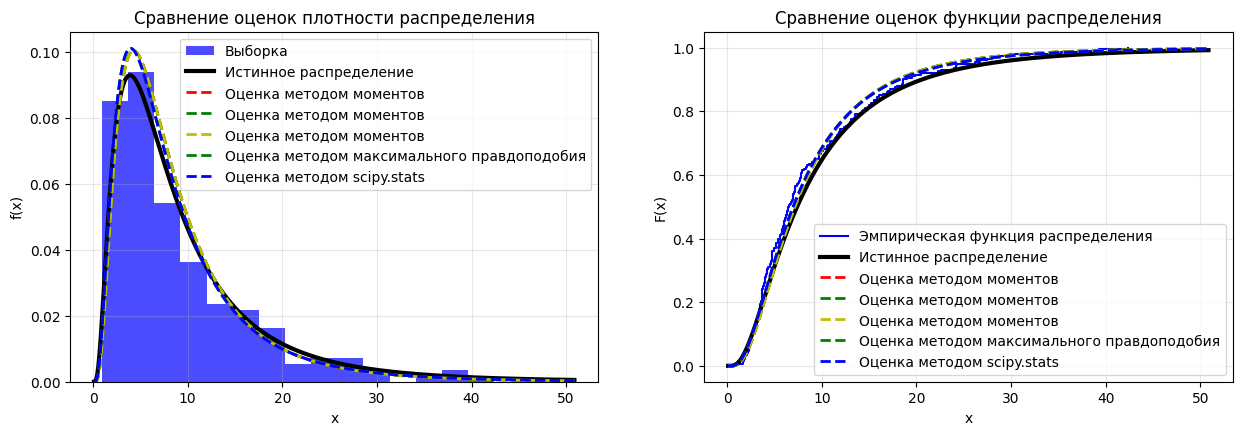

In [175]:
plt.figure(figsize=(15, 10))

x_plot = np.linspace(0.1, max(sample)*1.2, 1000)

#Исходная гистограмма
plt.subplot(2, 2, 1)
plt.hist(sample, bins=15, density=True, alpha=0.7, label='Выборка', color='blue')

# Теоретические распределения с разными оценками параметров
plt.plot(x_plot, stats.lognorm.pdf(x_plot, s=b, scale=np.exp(a)),'k-', linewidth=3, label='Истинное распределение')
plt.plot(x_plot, stats.lognorm.pdf(x_plot, s=b_moment1, scale=np.exp(a_moment1)), 'r--', linewidth=2, label='Оценка методом моментов')
plt.plot(x_plot, stats.lognorm.pdf(x_plot, s=b_moment2, scale=np.exp(a_moment2)), 'g--', linewidth=2, label='Оценка методом моментов')
plt.plot(x_plot, stats.lognorm.pdf(x_plot, s=b_moment3, scale=np.exp(a_moment3)), 'y--', linewidth=2, label='Оценка методом моментов')
plt.plot(x_plot, stats.lognorm.pdf(x_plot, s=b_mle, scale=np.exp(a_mle)), 'g--', linewidth=2, label='Оценка методом максимального правдоподобия')
plt.plot(x_plot, stats.lognorm.pdf(x_plot, s=b_est_scipy, scale=np.exp(a_est_scipy)), 'b--', linewidth=2, label='Оценка методом scipy.stats')

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Сравнение оценок плотности распределения')
plt.legend()
plt.grid(True, alpha=0.3)

# Функции распределения
plt.subplot(2, 2, 2)
plt.step(x_sorted, y_esdf, where='post', label='Эмпирическая функция распределения', color='blue')

plt.plot(x_plot, stats.lognorm.cdf(x_plot, s=b, scale=np.exp(a)), 'k-', linewidth=3, label='Истинное распределение')
plt.plot(x_plot, stats.lognorm.cdf(x_plot, s=b_moment1, scale=np.exp(a_moment1)), 'r--', linewidth=2, label='Оценка методом моментов')
plt.plot(x_plot, stats.lognorm.cdf(x_plot, s=b_moment2, scale=np.exp(a_moment2)), 'g--', linewidth=2, label='Оценка методом моментов')
plt.plot(x_plot, stats.lognorm.cdf(x_plot, s=b_moment3, scale=np.exp(a_moment3)), 'y--', linewidth=2, label='Оценка методом моментов')
plt.plot(x_plot, stats.lognorm.cdf(x_plot, s=b_mle, scale=np.exp(a_mle)), 'g--', linewidth=2, label='Оценка методом максимального правдоподобия')
plt.plot(x_plot, stats.lognorm.cdf(x_plot, s=b_est_scipy, scale=np.exp(a_est_scipy)), 'b--', linewidth=2, label='Оценка методом scipy.stats')

plt.xlabel('x')
plt.ylabel('F(x)')
plt.title('Сравнение оценок функции распределения')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()




In [176]:
print("Ошибки оценок параметров:")

methods = ['scipy.stats', 'Моменты (α₁, μ₂)', 'Моменты (α₂, μ₂)', 
           'Моменты (α₁, α₂)', 'Макс. правдоподобие']

a_estimates = [a_est_scipy, a_moment1, a_moment2, a_moment3, a_mle]
b_estimates = [b_est_scipy, b_moment1, b_moment2, b_moment3, b_mle]

for i, method in enumerate(methods):
    a_error = abs(a_estimates[i] - a)
    b_error = abs(b_estimates[i] - b)
    print(f"{method}: a_error = {a_error:.4f}, b_error = {b_error:.4f}")

Ошибки оценок параметров:
scipy.stats: a_error = 0.0587, b_error = 0.0497
Моменты (α₁, μ₂): a_error = 0.0322, b_error = 0.0808
Моменты (α₂, μ₂): a_error = 0.0312, b_error = 0.0822
Моменты (α₁, α₂): a_error = 0.0312, b_error = 0.0822
Макс. правдоподобие: a_error = 0.0587, b_error = 0.0497
